In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

2.

In [ ]:
student_df = pd.read_csv('5_student_final_grades.csv')
student_df.isnull().sum()

,0
weekly_study_hours,0
attendance_rate,0
tutoring,0
major,0
midterm_score,40
avg_assignment_score,0
online_courses,0
club_activity,44
final_exam_score,0


3.

<Axes: xlabel='midterm_score', ylabel='final_exam_score'>

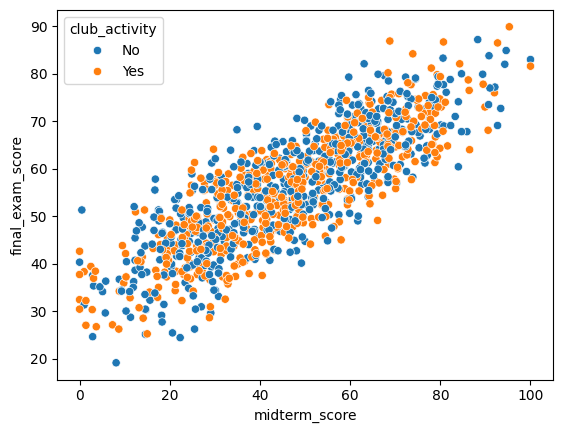

In [ ]:
sns.scatterplot(data=student_df, x='midterm_score', y='final_exam_score', hue='club_activity')

4.

<Axes: xlabel='final_exam_score', ylabel='Density'>

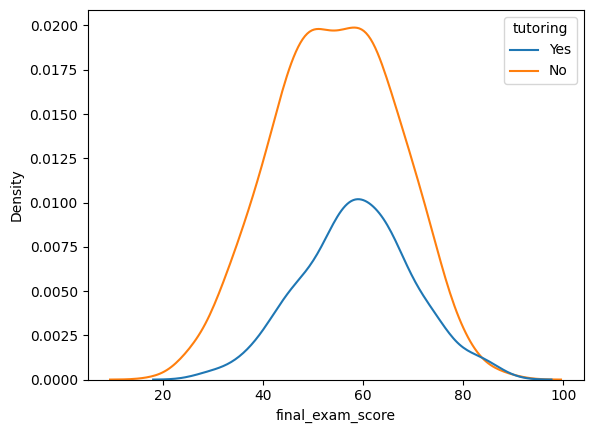

In [ ]:
sns.kdeplot(data=student_df, x='final_exam_score', hue='tutoring')

5.

In [ ]:
student_df.groupby(['major'])[['weekly_study_hours', 'avg_assignment_score']].mean()

,weekly_study_hours,avg_assignment_score
major,,
공학,20.817021,78.940678
사회,21.035242,80.684211
예체능,21.289720,79.502370
인문,20.548507,78.839416
자연,20.689815,80.621495


6.

In [ ]:
student_pre = student_df.copy()

student_pre['midterm_score'].fillna(student_pre['midterm_score'].mean(), inplace=True)
student_pre.dropna(subset=['club_activity'], inplace=True)

/tmp/ipykernel_1234/198789545.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_pre['midterm_score'].fillna(student_pre['midterm_score'].mean(), inplace=True)


7.

In [ ]:
student_pre['tutoring'] = student_pre['tutoring'].replace({'Yes' : 1, 'No' : 0})
student_pre['club_activity'] = student_pre['club_activity'].replace({'Yes' : 1, 'No' : 0})

/tmp/ipykernel_1234/1432228660.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  student_pre['tutoring'] = student_pre['tutoring'].replace({'Yes' : 1, 'No' : 0})
/tmp/ipykernel_1234/1432228660.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  student_pre['club_activity'] = student_pre['club_activity'].replace({'Yes' : 1, 'No' : 0})


8.

In [ ]:
student_encoded = pd.get_dummies(data=student_pre, columns=['major'])

X = student_encoded.drop(columns=['final_exam_score'])
y = student_encoded['final_exam_score']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

9.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

10.

In [ ]:
model_knn = KNeighborsRegressor(n_neighbors=5)

model_knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

11.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, max_features=5, random_state=42)

model_rf.fit(X_train_scaled, y_train)

print(pd.DataFrame([model_rf.feature_importances_], columns=X.columns))

   weekly_study_hours  attendance_rate  tutoring  midterm_score  \
0            0.284392         0.069773  0.018632       0.457234   

   avg_assignment_score  online_courses  club_activity  major_공학  major_사회  \
0              0.095174        0.039942       0.006507  0.005468  0.005421   

   major_예체능  major_인문  major_자연  
0   0.004859  0.007005  0.005594  


In [ ]:
답안11='midterm_score'

12.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

knn_pred = model_knn.predict(X_valid_scaled)
rf_pred = model_rf.predict(X_valid_scaled)

print('KNN')
print('RMSE', np.sqrt(mean_squared_error(y_valid, knn_pred)))
print('R2', r2_score(y_valid, knn_pred))

print('Random Forest')
print('RMSE', np.sqrt(mean_squared_error(y_valid, rf_pred)))
print('R2', r2_score(y_valid, rf_pred))

KNN
RMSE 6.999531757738243
R2 0.6635730898676855
Random Forest
RMSE 5.909892081035216
R2 0.7601653923669385


13.

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3089.7451 - val_loss: 2976.8308
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2743.2866 - val_loss: 2527.3408
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2166.2480 - val_loss: 1798.0426
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1351.1250 - val_loss: 918.5369
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 562.5546 - val_loss: 277.8916
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 147.7563 - val_loss: 84.3064
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 69.1367 - val_loss: 64.3123
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 58.5534 - val_loss: 57.7437
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 54.0493 - val_loss: 54.6914
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 50.9346 - val_loss: 52.8837
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 48.4028 - val_loss: 50.8440
Epoch 12/100
29/29 ━

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_student_data = np.array([[20, 95, 1, 85.0, 90.0, 30, 1, 0, 0, 0, 1, 0]])

In [ ]:
new_student_data_scaled = scaler.transform(new_student_data)

predicted_grade_dl = model.predict(new_student_data_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
